# Tabular In-Context Learning as Bayesian Kernel Regression

Companion notebook to `tabular_icl_kernel_bayesian.pdf`.

This notebook walks through the paper's argument on a 2-D synthetic
prior. We start with $k$-NN, generalize to RBF Nadaraya-Watson, expose
the failure modes of a fixed kernel, then replace the kernel with a
learned attention kernel and train it by cross-entropy on prior-sampled
episodes. We finally compare the trained ICL model to the Bayes
posterior predictive computed by importance sampling.

**Bottom line.** A single-layer attention is Nadaraya-Watson with a
learned kernel $K_\theta(x, x') = \exp(x^\top M\, x' / \tau)$ where
$M = W_Q^\top W_K$. The kernel form is underdetermined; the prior
supplies the target; cross-entropy on prior-sampled episodes selects
the kernel that approximates the Bayes posterior predictive under the
prior.


## 0. Setup

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| Device:', device)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

PyTorch: 2.5.1 | Device: cuda


## 1. The synthetic prior

Each task is a random linear binary classifier in $\mathbb{R}^2$ with
5% label noise:

- $w \sim \mathrm{Unif}(\text{unit circle})$
- $b \sim \mathrm{Unif}(-0.5,\, 0.5)$
- $y = \mathbf{1}\{w^\top x + b > 0\}$ flipped with probability 0.05
- $x \sim \mathcal{N}(0,\, I_2)$


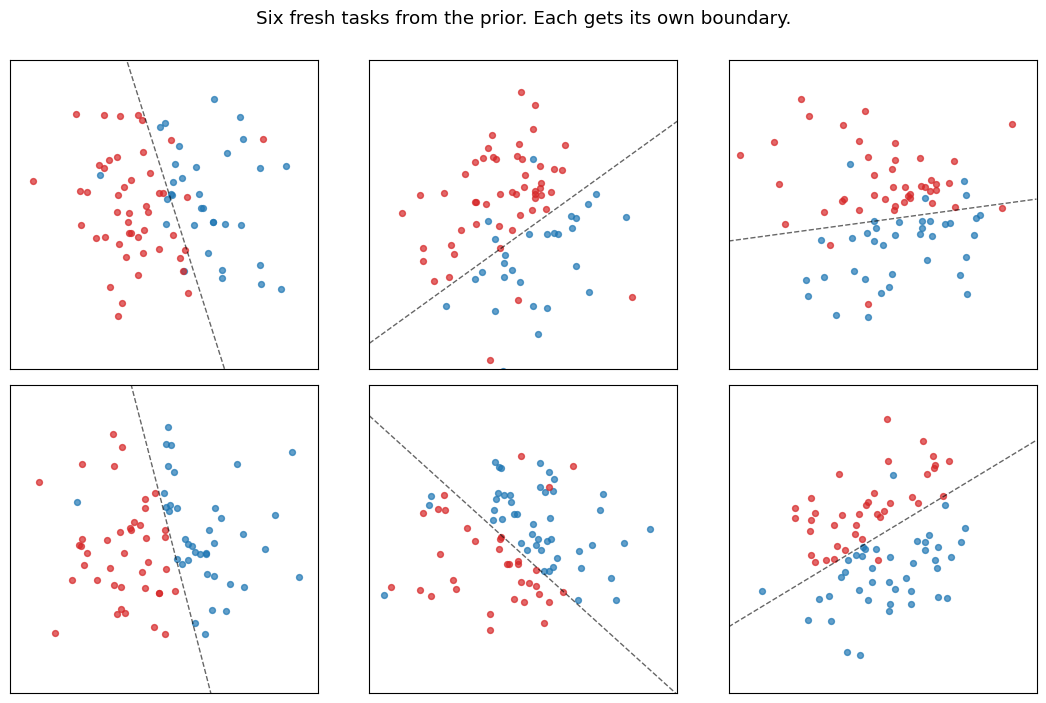

In [2]:
NOISE = 0.05

def sample_task():
    angle = np.random.uniform(0, 2*np.pi)
    w = np.array([np.cos(angle), np.sin(angle)], dtype=np.float32)
    b = np.float32(np.random.uniform(-0.5, 0.5))
    return w, b

def label_from(X, w, b, noise=NOISE):
    score = X @ w + b
    y = (score > 0).astype(np.int64)
    flips = np.random.rand(len(y)) < noise
    return np.where(flips, 1 - y, y)

def sample_episode(n_ctx, n_q):
    w, b = sample_task()
    X = np.random.randn(n_ctx + n_q, 2).astype(np.float32)
    y = label_from(X, w, b)
    return X[:n_ctx], y[:n_ctx], X[n_ctx:], y[n_ctx:], w, b

# Six fresh tasks
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax in axes.flat:
    Xc, yc, Xq, yq, w, b = sample_episode(80, 120)
    ax.scatter(Xc[yc==0, 0], Xc[yc==0, 1], c='C0', s=18, alpha=0.7)
    ax.scatter(Xc[yc==1, 0], Xc[yc==1, 1], c='C3', s=18, alpha=0.7)
    xs = np.linspace(-3, 3, 50)
    if abs(w[1]) > 1e-6:
        ax.plot(xs, -(w[0]*xs + b)/w[1], 'k--', lw=1, alpha=0.6)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Six fresh tasks from the prior. Each gets its own boundary.', y=1.0)
plt.tight_layout(); plt.savefig('fig_prior_tasks.png', dpi=140, bbox_inches='tight'); plt.show()

## 2. $k$-NN baseline: a hard neighborhood

The simplest predictor uses the $k$ nearest context points and votes.

In [3]:
def knn_predict_proba(X_ctx, y_ctx, X_q, k=5, n_classes=2):
    # Squared Euclidean distance from each query to each context point
    d2 = ((X_q[:, None, :] - X_ctx[None, :, :]) ** 2).sum(-1)
    idx = np.argsort(d2, axis=1)[:, :k]                          # [Q, k]
    one_hot = np.eye(n_classes, dtype=np.float32)[y_ctx]         # [N_c, C]
    return one_hot[idx].mean(axis=1)                             # [Q, C]

# Evaluate on a held-out task
np.random.seed(42)
Xc, yc, Xq, yq, w, b = sample_episode(64, 200)
p_knn = knn_predict_proba(Xc, yc, Xq, k=5)
acc_knn = (p_knn.argmax(-1) == yq).mean()
print(f'5-NN accuracy on a held-out task: {acc_knn:.3f}')

5-NN accuracy on a held-out task: 0.850


## 3. Nadaraya-Watson with the RBF kernel: a soft neighborhood

Weight every context point by $k_\sigma(x_q, x_i) = \exp(-\|x_q - x_i\|^2 / 2\sigma^2)$,
then take a softmax-normalized average of context labels.

In [4]:
def rbf_nw_predict_proba(X_ctx, y_ctx, X_q, sigma=0.5, n_classes=2):
    d2 = ((X_q[:, None, :] - X_ctx[None, :, :]) ** 2).sum(-1)
    log_w = -d2 / (2 * sigma**2)
    log_w = log_w - log_w.max(axis=1, keepdims=True)
    w = np.exp(log_w)
    w = w / w.sum(axis=1, keepdims=True)
    one_hot = np.eye(n_classes, dtype=np.float32)[y_ctx]
    return w @ one_hot

p_rbf = rbf_nw_predict_proba(Xc, yc, Xq, sigma=0.5)
acc_rbf = (p_rbf.argmax(-1) == yq).mean()
print(f'RBF Nadaraya-Watson accuracy (sigma=0.5): {acc_rbf:.3f}')

RBF Nadaraya-Watson accuracy (sigma=0.5): 0.790


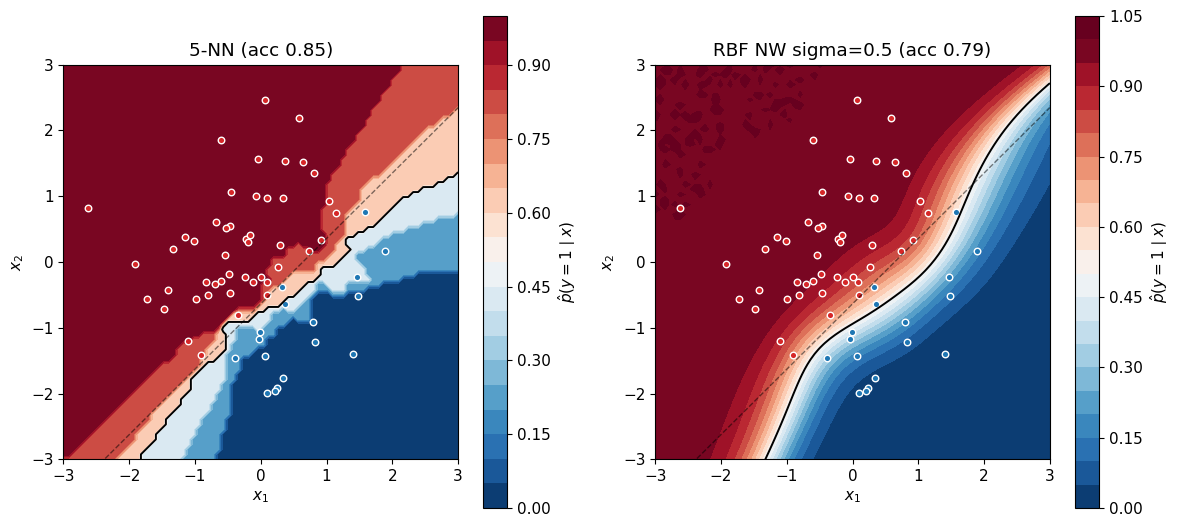

In [5]:
def plot_decision_2d(predict_fn, X_ctx, y_ctx, w, b, title, ax, grid_n=80):
    xs = np.linspace(-3, 3, grid_n).astype(np.float32)
    XX, YY = np.meshgrid(xs, xs, indexing='xy')
    G = np.stack([XX.ravel(), YY.ravel()], axis=-1)
    p = predict_fn(X_ctx, y_ctx, G)[:, 1].reshape(grid_n, grid_n)
    im = ax.contourf(XX, YY, p, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label=r'$\hat{p}(y=1\mid x)$')
    ax.contour(XX, YY, p, levels=[0.5], colors='black', linewidths=1.4)
    ax.scatter(X_ctx[y_ctx==0, 0], X_ctx[y_ctx==0, 1], c='C0', s=22, edgecolor='white')
    ax.scatter(X_ctx[y_ctx==1, 0], X_ctx[y_ctx==1, 1], c='C3', s=22, edgecolor='white')
    xs_line = np.linspace(-3, 3, 50)
    if abs(w[1]) > 1e-6:
        ax.plot(xs_line, -(w[0]*xs_line + b)/w[1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
    ax.set_title(title); ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
plot_decision_2d(lambda Xc, yc, Xq: knn_predict_proba(Xc, yc, Xq, k=5),
                 Xc, yc, w, b, f'5-NN (acc {acc_knn:.2f})', axes[0])
plot_decision_2d(lambda Xc, yc, Xq: rbf_nw_predict_proba(Xc, yc, Xq, sigma=0.5),
                 Xc, yc, w, b, f'RBF NW sigma=0.5 (acc {acc_rbf:.2f})', axes[1])
plt.tight_layout(); plt.savefig('fig_knn_vs_rbf.png', dpi=140, bbox_inches='tight'); plt.show()

## 4. The fixed-kernel ceiling

A pre-selected RBF kernel works on this clean 2-D prior. It breaks
when features have heterogeneous scale or include irrelevant noise
dimensions, both of which are routine on real tabular data.

Below we add two pure-noise dimensions to the features, compute
predictions with RBF NW on the augmented input and compare to RBF NW
on the original 2-D features. The kernel sees the noise as part of
the geometry. Accuracy degrades.

extra noise dims =  0   clean RBF NW 0.883   noisy RBF NW 0.883
extra noise dims =  2   clean RBF NW 0.883   noisy RBF NW 0.825
extra noise dims =  6   clean RBF NW 0.883   noisy RBF NW 0.733
extra noise dims = 14   clean RBF NW 0.883   noisy RBF NW 0.663
extra noise dims = 30   clean RBF NW 0.883   noisy RBF NW 0.607


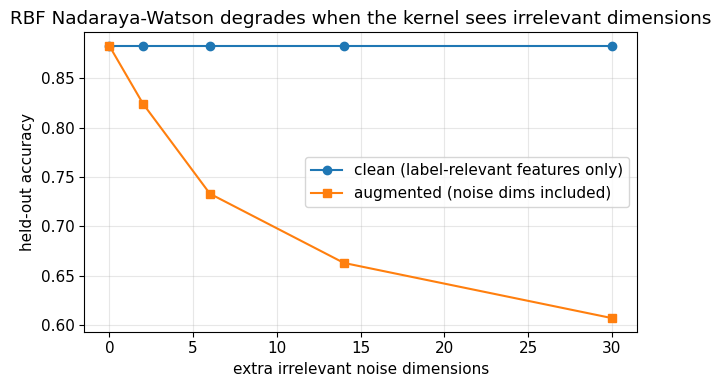

\nThe fixed RBF kernel cannot down-weight irrelevant directions.
A learned kernel can, by choosing W_Q, W_K to project them out.


In [6]:
def sample_episode_with_noise_dims(n_ctx, n_q, n_noise=2):
    # The label is determined by the first 2 features, but the kernel sees all
    Xc2, yc, Xq2, yq, w, b = sample_episode(n_ctx, n_q)
    Nc, Nq = Xc2.shape[0], Xq2.shape[0]
    Xc_noise = np.random.randn(Nc, n_noise).astype(np.float32)
    Xq_noise = np.random.randn(Nq, n_noise).astype(np.float32)
    Xc = np.concatenate([Xc2, Xc_noise], axis=1)
    Xq = np.concatenate([Xq2, Xq_noise], axis=1)
    return Xc2, Xq2, Xc, yc, Xq, yq, w, b

results = []
for n_noise in [0, 2, 6, 14, 30]:
    accs = []
    for trial in range(20):
        np.random.seed(1000 + trial)
        Xc2, Xq2, Xc, yc, Xq, yq, _, _ = sample_episode_with_noise_dims(64, 200, n_noise=n_noise)
        # RBF NW on raw (label-determining) features
        p_clean = rbf_nw_predict_proba(Xc2, yc, Xq2, sigma=0.5)
        a_clean = (p_clean.argmax(-1) == yq).mean()
        # RBF NW on features augmented with n_noise irrelevant noise dims
        p_noisy = rbf_nw_predict_proba(Xc, yc, Xq, sigma=0.5)
        a_noisy = (p_noisy.argmax(-1) == yq).mean()
        accs.append((a_clean, a_noisy))
    accs = np.array(accs)
    results.append((n_noise, accs[:, 0].mean(), accs[:, 1].mean()))
    print(f'extra noise dims = {n_noise:2d}   clean RBF NW {accs[:, 0].mean():.3f}   noisy RBF NW {accs[:, 1].mean():.3f}')

results = np.array(results)
plt.figure(figsize=(6.5, 4))
plt.plot(results[:, 0], results[:, 1], '-o', label='clean (label-relevant features only)')
plt.plot(results[:, 0], results[:, 2], '-s', label='augmented (noise dims included)')
plt.xlabel('extra irrelevant noise dimensions')
plt.ylabel('held-out accuracy')
plt.title('RBF Nadaraya-Watson degrades when the kernel sees irrelevant dimensions')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.savefig('fig_failure_modes.png', dpi=140, bbox_inches='tight'); plt.show()
print('\\nThe fixed RBF kernel cannot down-weight irrelevant directions.')
print('A learned kernel can, by choosing W_Q, W_K to project them out.')

## 5. Single-layer attention as a learned kernel

Replace the fixed RBF with a learned scoring operator $M = W_Q^\top W_K$.
With one-hot label values, a single attention head implements
$$
\hat{p}_\theta(y_q = c \mid x_q) = \sum_i \frac{K_\theta(x_q, x_i)}{\sum_j K_\theta(x_q, x_j)}\,\mathbf{1}\{y_i = c\},
\qquad K_\theta(x, x') = \exp(\langle W_Q x, W_K x'\rangle / \sqrt{d_k}).
$$
The next cell verifies this numerically: model output equals the
explicit NW formula to floating-point precision.

In [7]:
# Single attention head with one-hot label values: NW with a learned kernel.
class SingleLayerNWAttention(nn.Module):
    def __init__(self, d_x=2, d_k=16, n_classes=2):
        super().__init__()
        self.W_q = nn.Linear(d_x, d_k, bias=False)
        self.W_k = nn.Linear(d_x, d_k, bias=False)
        self.scale = d_k ** -0.5
        self.n_classes = n_classes

    def kernel(self, X_q, X_ctx):
        Q = self.W_q(X_q); K = self.W_k(X_ctx)
        return torch.exp(torch.einsum('...qk,...nk->...qn', Q, K) * self.scale)

    def forward(self, X_ctx, y_ctx, X_q):
        K = self.kernel(X_q, X_ctx)
        alpha = K / K.sum(dim=-1, keepdim=True).clamp(min=1e-30)
        Y = F.one_hot(y_ctx, num_classes=self.n_classes).float()
        return torch.einsum('...qn,...nc->...qc', alpha, Y)

torch.manual_seed(1)
model = SingleLayerNWAttention(d_x=2, d_k=16).to(device)

Xc, yc, Xq, yq, _, _ = sample_episode(64, 16)
Xc_t = torch.tensor(Xc).unsqueeze(0).to(device)
yc_t = torch.tensor(yc).unsqueeze(0).to(device)
Xq_t = torch.tensor(Xq).unsqueeze(0).to(device)

with torch.no_grad():
    p_model = model(Xc_t, yc_t, Xq_t)
    K = model.kernel(Xq_t, Xc_t)
    alpha = K / K.sum(-1, keepdim=True)
    Y = F.one_hot(yc_t, num_classes=2).float()
    p_manual = torch.einsum('bqn,bnc->bqc', alpha, Y)

diff = (p_model - p_manual).abs().max().item()
print(f'Maximum |attention output - explicit NW formula|: {diff:.2e}')
assert diff < 1e-6

Maximum |attention output - explicit NW formula|: 0.00e+00


## 6. Training: cross-entropy on prior-sampled episodes

Each step samples a fresh batch of episodes from the prior, computes
cross-entropy on the query labels, and updates $\theta = (W_Q, W_K)$.
The model is forced to find a kernel that generalizes across the prior;
no specific boundary is reusable.

In [8]:
def sample_batch(B, n_ctx, n_q):
    Xc = np.empty((B, n_ctx, 2), dtype=np.float32)
    yc = np.empty((B, n_ctx), dtype=np.int64)
    Xq = np.empty((B, n_q, 2), dtype=np.float32)
    yq = np.empty((B, n_q), dtype=np.int64)
    for b in range(B):
        xc, ycb, xq, yqb, _, _ = sample_episode(n_ctx, n_q)
        Xc[b] = xc; yc[b] = ycb; Xq[b] = xq; yq[b] = yqb
    return tuple(torch.tensor(t) for t in (Xc, yc, Xq, yq))

def nll_from_probs(p, y):
    return -torch.log(p.clamp(min=1e-12).gather(-1, y.unsqueeze(-1)).squeeze(-1))

def train(model, n_steps=1500, B=32, n_ctx_range=(4, 96), n_q=32, lr=3e-3, log_every=100):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses, accs = [], []
    model.train()
    for step in range(1, n_steps + 1):
        n_ctx = int(np.random.randint(n_ctx_range[0], n_ctx_range[1] + 1))
        Xc, yc, Xq, yq = (t.to(device) for t in sample_batch(B, n_ctx, n_q))
        p = model(Xc, yc, Xq)
        loss = nll_from_probs(p, yq).mean()
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        with torch.no_grad():
            acc = (p.argmax(-1) == yq).float().mean().item()
        losses.append(loss.item()); accs.append(acc)
        if step == 1 or step % log_every == 0:
            print(f'step {step:5d}  loss {loss.item():.3f}  acc {acc:.3f}  n_ctx {n_ctx}')
    return losses, accs

torch.manual_seed(0); np.random.seed(0)
model = SingleLayerNWAttention(d_x=2, d_k=16).to(device)
losses, accs = train(model, n_steps=1500)

step     1  loss 0.649  acc 0.620  n_ctx 48


step   100  loss 0.461  acc 0.843  n_ctx 93


step   200  loss 3.552  acc 0.683  n_ctx 4


step   300  loss 0.432  acc 0.855  n_ctx 43


step   400  loss 0.392  acc 0.867  n_ctx 54


...

step  1100  loss 0.396  acc 0.876  n_ctx 91


step  1200  loss 0.508  acc 0.788  n_ctx 16


step  1300  loss 0.390  acc 0.877  n_ctx 85


step  1400  loss 0.415  acc 0.854  n_ctx 55


step  1500  loss 0.367  acc 0.897  n_ctx 82


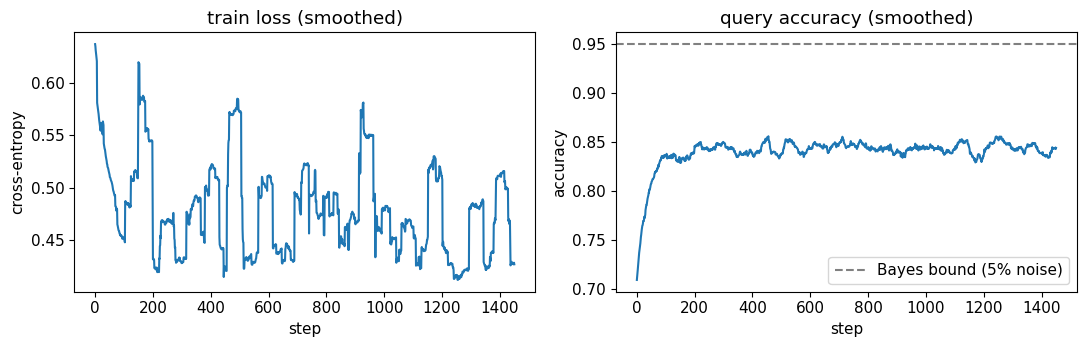

In [9]:
def smooth(x, w=50):
    x = np.asarray(x); k = np.ones(w) / w
    return np.convolve(x, k, mode='valid')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(smooth(losses)); ax[0].set_title('train loss (smoothed)'); ax[0].set_xlabel('step')
ax[0].set_ylabel('cross-entropy')
ax[1].plot(smooth(accs));   ax[1].set_title('query accuracy (smoothed)'); ax[1].set_xlabel('step')
ax[1].set_ylabel('accuracy'); ax[1].axhline(0.95, color='gray', ls='--', label='Bayes bound (5% noise)')
ax[1].legend()
plt.tight_layout(); plt.savefig('fig_training_curves.png', dpi=140, bbox_inches='tight'); plt.show()

## 7. What did SGD discover?

We visualize two things side by side. Left: the learned kernel
$K_\theta(x^\star, \cdot)$ from a fixed query point $x^\star$. Right:
the induced decision function on a held-out task with the trained
context overlaid.

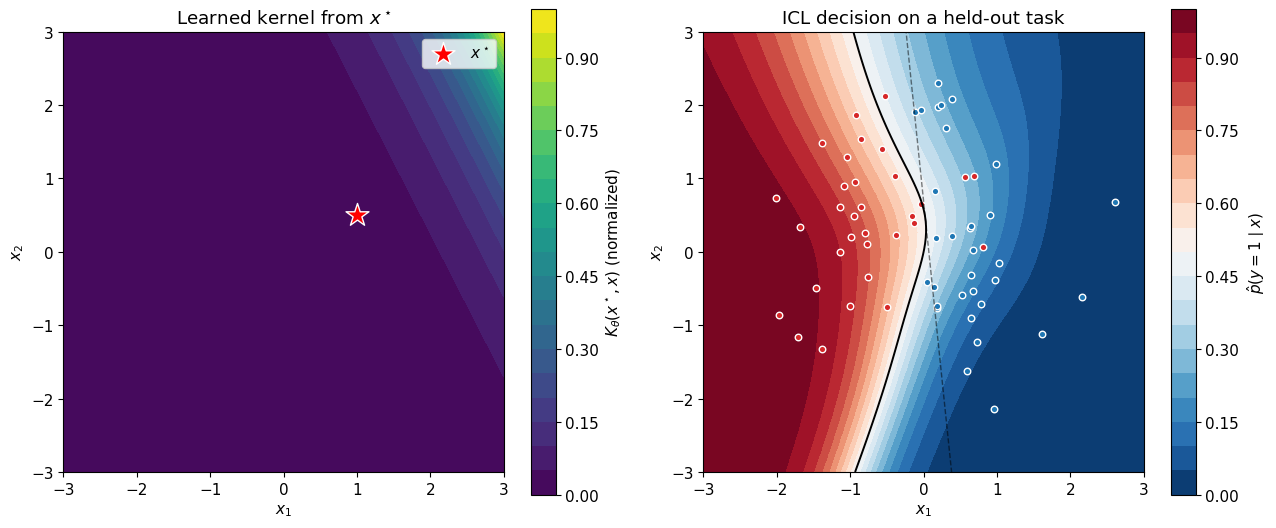

In [10]:
@torch.no_grad()
def visualize_kernel_and_decision(model, n_ctx=64, grid_n=80, x_star=(1.0, 0.5)):
    model.eval()
    Xc_np, yc_np, _, _, w, b = sample_episode(n_ctx, n_q=2)
    Xc_t = torch.tensor(Xc_np, device=device).unsqueeze(0)
    yc_t = torch.tensor(yc_np, device=device).unsqueeze(0)

    xs = np.linspace(-3, 3, grid_n).astype(np.float32)
    XX, YY = np.meshgrid(xs, xs, indexing='xy')
    grid = np.stack([XX.ravel(), YY.ravel()], axis=-1)
    grid_t = torch.tensor(grid, device=device).unsqueeze(0)

    p1 = model(Xc_t, yc_t, grid_t)[0, :, 1].cpu().numpy().reshape(grid_n, grid_n)

    x_star_t = torch.tensor([x_star], device=device, dtype=torch.float32).unsqueeze(0)
    K = model.kernel(x_star_t, grid_t)[0, 0].cpu().numpy().reshape(grid_n, grid_n)
    K = K / K.max()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
    im = axes[0].contourf(XX, YY, K, levels=20, cmap='viridis')
    plt.colorbar(im, ax=axes[0], label=r'$K_\theta(x^\star, x)$ (normalized)')
    axes[0].scatter(*x_star, color='red', marker='*', s=300, edgecolors='white', label=r'$x^\star$')
    axes[0].set_title(r'Learned kernel from $x^\star$')
    axes[0].set_xlabel(r'$x_1$'); axes[0].set_ylabel(r'$x_2$'); axes[0].legend()
    axes[0].set_aspect('equal')

    im = axes[1].contourf(XX, YY, p1, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[1], label=r'$\hat{p}(y=1\mid x)$')
    axes[1].contour(XX, YY, p1, levels=[0.5], colors='black', linewidths=1.4)
    axes[1].scatter(Xc_np[yc_np==0, 0], Xc_np[yc_np==0, 1], c='C0', s=22, edgecolor='white')
    axes[1].scatter(Xc_np[yc_np==1, 0], Xc_np[yc_np==1, 1], c='C3', s=22, edgecolor='white')
    xs_line = np.linspace(-3, 3, 50)
    if abs(w[1]) > 1e-6:
        axes[1].plot(xs_line, -(w[0]*xs_line + b)/w[1], 'k--', lw=1, alpha=0.5)
    axes[1].set_xlim(-3, 3); axes[1].set_ylim(-3, 3); axes[1].set_aspect('equal')
    axes[1].set_title('ICL decision on a held-out task')
    axes[1].set_xlabel(r'$x_1$'); axes[1].set_ylabel(r'$x_2$')
    plt.tight_layout(); plt.savefig('fig_kernel_heatmap.png', dpi=140, bbox_inches='tight'); plt.show()

torch.manual_seed(101); np.random.seed(101)
visualize_kernel_and_decision(model)

## 7b. ICL in action: same model, different contexts, different functions

The defining property of in-context learning is that a single set of
parameters $\theta$ produces \emph{different} predictive functions
when given different contexts. The model never trains on your dataset
specifically; it adapts to whatever labeled rows you hand it.

Below we feed the same trained model three independently sampled
tasks. Each task has its own random boundary direction $w$ and
offset $b$. Without changing $\theta$ at all, the model produces a
different decision function for each context.


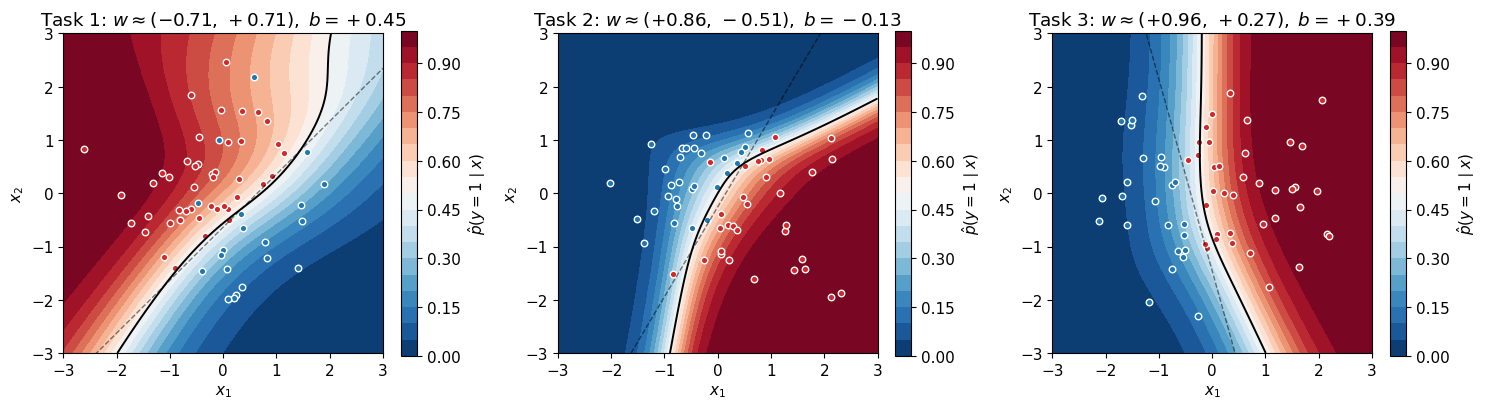

In [11]:
@torch.no_grad()
def visualize_icl_across_tasks(model, n_tasks=3, n_ctx=64, grid_n=80, seed=42):
    rng_np = np.random.RandomState(seed)
    rng_th = torch.Generator().manual_seed(seed)
    np.random.seed(seed); torch.manual_seed(seed)
    fig, axes = plt.subplots(1, n_tasks, figsize=(5*n_tasks, 5.0))
    if n_tasks == 1:
        axes = [axes]
    xs = np.linspace(-3, 3, grid_n).astype(np.float32)
    XX, YY = np.meshgrid(xs, xs, indexing='xy')
    G = np.stack([XX.ravel(), YY.ravel()], axis=-1).astype(np.float32)
    G_t = torch.tensor(G, device=device).unsqueeze(0)
    for i, ax in enumerate(axes):
        Xc_np, yc_np, _, _, w, b = sample_episode(n_ctx, n_q=2)
        Xc_t = torch.tensor(Xc_np, device=device).unsqueeze(0)
        yc_t = torch.tensor(yc_np, device=device).unsqueeze(0)
        p = model(Xc_t, yc_t, G_t)[0, :, 1].cpu().numpy().reshape(grid_n, grid_n)
        im = ax.contourf(XX, YY, p, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, label=r'$\hat{p}(y=1\mid x)$', fraction=0.046)
        ax.contour(XX, YY, p, levels=[0.5], colors='black', linewidths=1.4)
        ax.scatter(Xc_np[yc_np==0, 0], Xc_np[yc_np==0, 1], c='C0', s=22, edgecolor='white')
        ax.scatter(Xc_np[yc_np==1, 0], Xc_np[yc_np==1, 1], c='C3', s=22, edgecolor='white')
        xs_line = np.linspace(-3, 3, 50)
        if abs(w[1]) > 1e-6:
            ax.plot(xs_line, -(w[0]*xs_line + b)/w[1], 'k--', lw=1, alpha=0.5)
        ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
        ax.set_title(rf'Task {i+1}: $w \approx ({w[0]:+.2f},\,{w[1]:+.2f}),\;b={b:+.2f}$')
        ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
    plt.tight_layout()
    plt.savefig('fig_icl_in_action.png', dpi=140, bbox_inches='tight')
    plt.show()

visualize_icl_across_tasks(model, n_tasks=3)

Three different contexts, three different decision functions. The
model parameters $\theta$ are identical across the three panels; the
only thing that changes is which context the model is given to read.
The dashed line in each panel is the true boundary used to label the
context, and the model's $0.5$-probability contour tracks it
closely on each one. This is in-context learning: a single trained
function $f_\theta$ that becomes a different predictor for every
context you feed it, with no gradient updates at deployment.


### Bonus: same context, swapped labels

For a sharper variant of the demonstration, feed the model the same
context features but flip the labels. The model has no choice but to
reverse its decision: it can only read what is in the context.


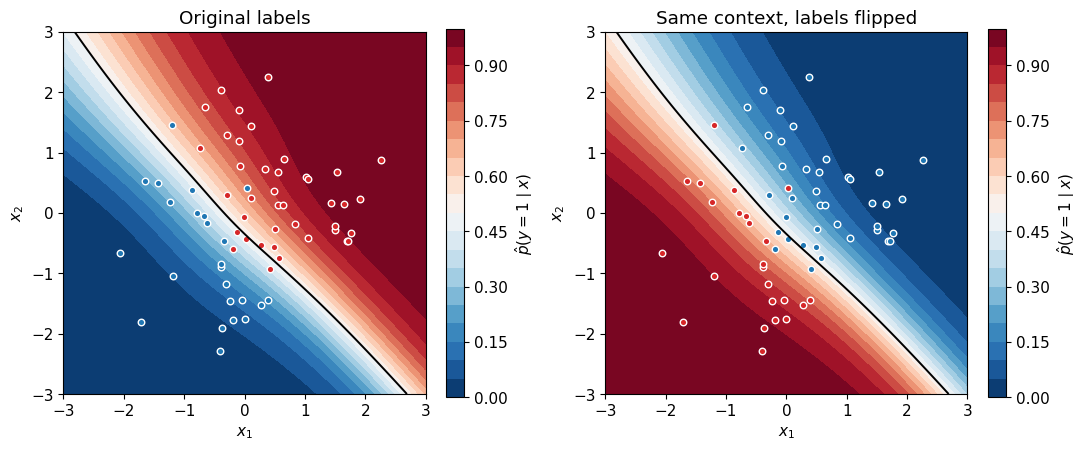

In [12]:
@torch.no_grad()
def visualize_label_flip(model, n_ctx=64, grid_n=80, seed=7):
    np.random.seed(seed); torch.manual_seed(seed)
    Xc_np, yc_np, _, _, w, b = sample_episode(n_ctx, n_q=2)
    yc_flip = 1 - yc_np                                      # invert all labels

    xs = np.linspace(-3, 3, grid_n).astype(np.float32)
    XX, YY = np.meshgrid(xs, xs, indexing='xy')
    G = np.stack([XX.ravel(), YY.ravel()], axis=-1).astype(np.float32)
    G_t = torch.tensor(G, device=device).unsqueeze(0)
    Xc_t = torch.tensor(Xc_np, device=device).unsqueeze(0)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.0))
    for ax, yc_use, title in zip(
        axes, [yc_np, yc_flip],
        ['Original labels', 'Same context, labels flipped']
    ):
        yc_t = torch.tensor(yc_use, device=device).unsqueeze(0)
        p = model(Xc_t, yc_t, G_t)[0, :, 1].cpu().numpy().reshape(grid_n, grid_n)
        im = ax.contourf(XX, YY, p, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, label=r'$\hat{p}(y=1\mid x)$', fraction=0.046)
        ax.contour(XX, YY, p, levels=[0.5], colors='black', linewidths=1.4)
        ax.scatter(Xc_np[yc_use==0, 0], Xc_np[yc_use==0, 1], c='C0', s=22, edgecolor='white')
        ax.scatter(Xc_np[yc_use==1, 0], Xc_np[yc_use==1, 1], c='C3', s=22, edgecolor='white')
        ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
        ax.set_title(title)
        ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
    plt.tight_layout()
    plt.savefig('fig_icl_label_flip.png', dpi=140, bbox_inches='tight')
    plt.show()

visualize_label_flip(model)

## 8b. Anatomy of the learned kernel

We can look directly at the trained scoring matrix $M = W_Q^\top W_K$
and decompose it into symmetric and antisymmetric parts:
$$
M \;=\; \underbrace{\tfrac{1}{2}(M + M^\top)}_{M_\text{sym}}
\;+\; \underbrace{\tfrac{1}{2}(M - M^\top)}_{M_\text{asym}}.
$$
The symmetric part captures mutual similarity (how alike $x$ and $x'$
are in either direction). The antisymmetric part captures directional
similarity (how much $K_\theta(x, x')$ differs from $K_\theta(x', x)$).
For our rotationally symmetric 2-D linear prior we expect
$M_\text{asym}$ to be small relative to $M_\text{sym}$.

In [13]:
import numpy.linalg as la

@torch.no_grad()
def extract_M_one_hot(model):
    Wq = model.W_q.weight.detach().cpu().numpy()  # [d_k, d_x]
    Wk = model.W_k.weight.detach().cpu().numpy()  # [d_k, d_x]
    return Wq.T @ Wk                                # [d_x, d_x]

M = extract_M_one_hot(model)
M_sym  = 0.5 * (M + M.T)
M_asym = 0.5 * (M - M.T)

print('M =')
print(M)
print('\nM_sym =')
print(M_sym)
print('\nM_asym =')
print(M_asym)
print(f'\n||M||_F       = {la.norm(M):.4f}')
print(f'||M_sym||_F   = {la.norm(M_sym):.4f}')
print(f'||M_asym||_F  = {la.norm(M_asym):.4f}')
print(f'asym / sym    = {la.norm(M_asym)/la.norm(M_sym):.4f}')

M =
[[ 5.0038133  -0.09037229]
 [-0.04864363  5.276938  ]]

M_sym =
[[ 5.0038133  -0.06950796]
 [-0.06950796  5.276938  ]]

M_asym =
[[ 0.         -0.02086433]
 [ 0.02086433  0.        ]]

||M||_F       = 7.2729
||M_sym||_F   = 7.2728
||M_asym||_F  = 0.0295
asym / sym    = 0.0041


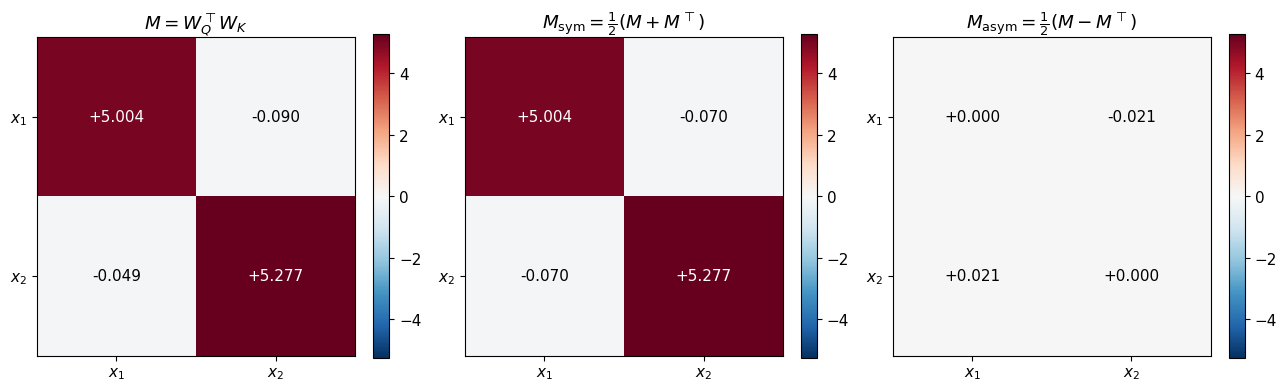

In [14]:
# Heatmaps of M, M_sym, M_asym
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
vmax = max(np.abs(M).max(), np.abs(M_sym).max(), np.abs(M_asym).max())
labels = ['$x_1$', '$x_2$']
for ax, mat, title in zip(axes, [M, M_sym, M_asym],
                          [r'$M = W_Q^\top W_K$',
                           r'$M_\mathrm{sym} = \frac{1}{2}(M + M^\top)$',
                           r'$M_\mathrm{asym} = \frac{1}{2}(M - M^\top)$']):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    ax.set_title(title)
    for (i, j), v in np.ndenumerate(mat):
        ax.text(j, i, f'{v:+.3f}', ha='center', va='center', fontsize=11,
                color='white' if abs(v) > 0.55*vmax else 'black')
plt.tight_layout()
plt.savefig('fig_M_decomposition_onehot.png', dpi=140, bbox_inches='tight')
plt.show()

Eigenvalues of M_sym:  [4.9871416 5.2936096]
Eigenvectors (columns):
[[-0.97242016 -0.23323606]
 [-0.23323606  0.97242016]]


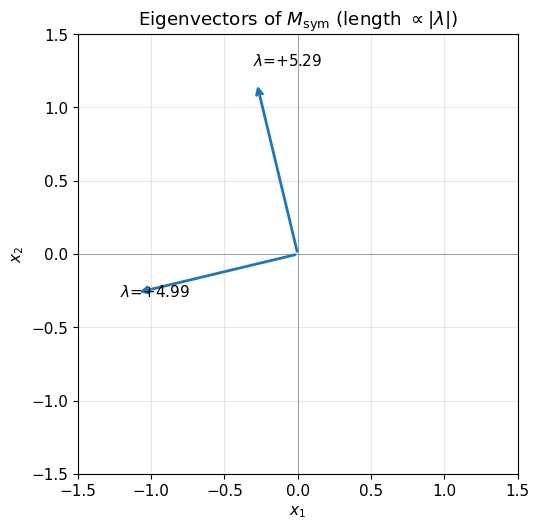

In [15]:
# Eigenstructure of M_sym (the metric-like part)
eigvals, eigvecs = la.eigh(M_sym)
print(f'Eigenvalues of M_sym:  {eigvals}')
print(f'Eigenvectors (columns):')
print(eigvecs)

# Plot eigenvectors as arrows from the origin, with length scaled by eigenvalue
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
for j in range(2):
    v = eigvecs[:, j] * eigvals[j] / max(abs(eigvals)) * 1.2
    ax.annotate('', xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='C0' if eigvals[j] > 0 else 'C3', lw=2))
    ax.text(v[0]*1.1, v[1]*1.1, f'$\\lambda$={eigvals[j]:+.2f}', fontsize=11)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title(r'Eigenvectors of $M_\mathrm{sym}$ (length $\propto |\lambda|$)')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
plt.tight_layout(); plt.show()

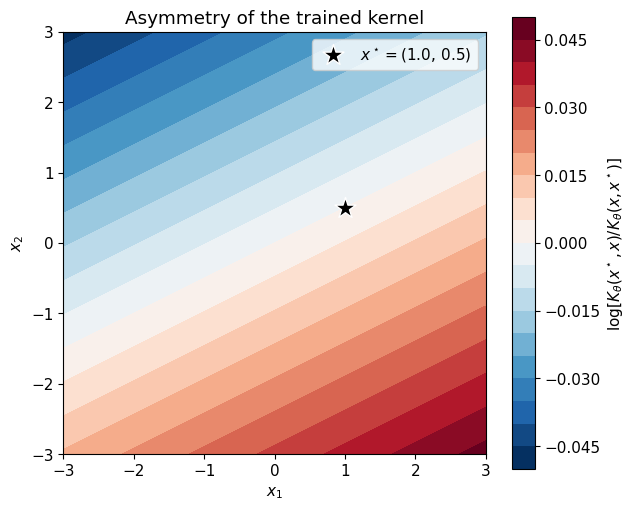

Max |log ratio| over the grid: 0.047
(Identically 0 if the kernel were symmetric.)


In [16]:
# The asymmetry ratio K(x_star, x') / K(x', x_star) over a 2-D grid.
# For a symmetric kernel this is identically 1.
@torch.no_grad()
def asymmetry_field(model, x_star=(1.0, 0.5), grid_n=80):
    model.eval()
    xs = np.linspace(-3, 3, grid_n).astype(np.float32)
    XX, YY = np.meshgrid(xs, xs, indexing='xy')
    G = np.stack([XX.ravel(), YY.ravel()], axis=-1)
    G_t = torch.tensor(G, device=device).unsqueeze(0)
    xs_t = torch.tensor([[x_star]], device=device, dtype=torch.float32)
    K_fwd = model.kernel(xs_t, G_t)[0, 0].cpu().numpy()
    K_bwd = model.kernel(G_t, xs_t)[0, :, 0].cpu().numpy()
    ratio = (K_fwd / np.maximum(K_bwd, 1e-30)).reshape(grid_n, grid_n)
    return XX, YY, ratio

XX, YY, ratio = asymmetry_field(model)
fig, ax = plt.subplots(figsize=(6.5, 5.4))
log_ratio = np.log(ratio)
m = max(abs(log_ratio.min()), abs(log_ratio.max()), 1e-9)
im = ax.contourf(XX, YY, log_ratio, levels=20, cmap='RdBu_r', vmin=-m, vmax=m)
plt.colorbar(im, ax=ax, label=r'$\log [K_\theta(x^\star,x)/K_\theta(x,x^\star)]$')
ax.scatter(1.0, 0.5, color='black', marker='*', s=250, edgecolors='white', label=r'$x^\star=(1.0,\,0.5)$')
ax.set_aspect('equal'); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_title('Asymmetry of the trained kernel')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Max |log ratio| over the grid: {np.abs(log_ratio).max():.3f}')
print(f'(Identically 0 if the kernel were symmetric.)')

## 8c. A variant with learned $W_V$

The single-layer model above keeps values fixed at one-hot labels,
which gives the exact NW correspondence. Modern attention heads
learn a value projection $W_V$ instead and use a linear readout to
turn the attention output into class logits. We define the variant
and train it on the same prior.

In [17]:
class LearnedValueAttention(nn.Module):
    # Single-layer attention with learned W_V + linear readout.
    # Tokens: t_i = W_x x_i + E_y(y_i) for context,
    #         t_q = W_x x_q + e_query for queries.
    # Q, K, V are linear projections of tokens.
    # Output:  softmax(linear(attention_output)).
    def __init__(self, d_x=2, d_model=64, d_k=16, n_classes=2):
        super().__init__()
        self.feat_proj = nn.Linear(d_x, d_model, bias=False)
        self.label_emb = nn.Embedding(n_classes, d_model)
        self.query_emb = nn.Parameter(torch.randn(d_model) * 0.02)
        self.W_q = nn.Linear(d_model, d_k, bias=False)
        self.W_k = nn.Linear(d_model, d_k, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.head = nn.Linear(d_model, n_classes)
        self.scale = d_k ** -0.5
        self.d_x = d_x; self.d_model = d_model; self.d_k = d_k
        self.n_classes = n_classes

    def tokens_ctx(self, X_ctx, y_ctx):
        return self.feat_proj(X_ctx) + self.label_emb(y_ctx)

    def tokens_query(self, X_q):
        return self.feat_proj(X_q) + self.query_emb

    def forward(self, X_ctx, y_ctx, X_q):
        t_ctx = self.tokens_ctx(X_ctx, y_ctx)
        t_q   = self.tokens_query(X_q)
        Q = self.W_q(t_q); K = self.W_k(t_ctx); V = self.W_v(t_ctx)
        scores = torch.einsum('bqk,bnk->bqn', Q, K) * self.scale
        alpha  = F.softmax(scores, dim=-1)
        o      = torch.einsum('bqn,bnd->bqd', alpha, V)
        return F.softmax(self.head(o), dim=-1)

torch.manual_seed(0); np.random.seed(0)
model_v = LearnedValueAttention().to(device)
losses_v, accs_v = train(model_v, n_steps=1500)

step     1  loss 0.696  acc 0.527  n_ctx 48


step   100  loss 0.495  acc 0.782  n_ctx 93


step   200  loss 0.823  acc 0.615  n_ctx 4


step   300  loss 0.540  acc 0.762  n_ctx 43


step   400  loss 0.504  acc 0.796  n_ctx 54


...

step  1100  loss 0.498  acc 0.796  n_ctx 91


step  1200  loss 0.616  acc 0.708  n_ctx 16


step  1300  loss 0.465  acc 0.799  n_ctx 85


step  1400  loss 0.485  acc 0.792  n_ctx 55


step  1500  loss 0.467  acc 0.811  n_ctx 82


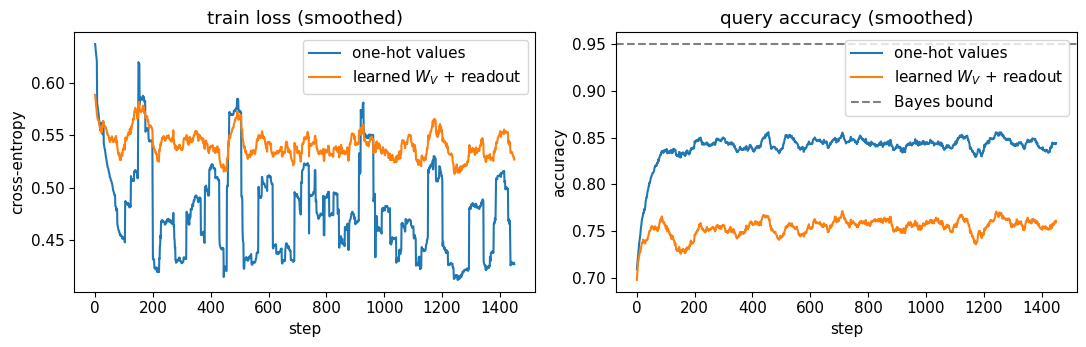

In [18]:
# Side-by-side training curves (one-hot vs learned-W_V model)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(smooth(losses),   label='one-hot values', color='C0')
ax[0].plot(smooth(losses_v), label=r'learned $W_V$ + readout', color='C1')
ax[0].set_xlabel('step'); ax[0].set_ylabel('cross-entropy'); ax[0].set_title('train loss (smoothed)')
ax[0].legend()
ax[1].plot(smooth(accs),   label='one-hot values', color='C0')
ax[1].plot(smooth(accs_v), label=r'learned $W_V$ + readout', color='C1')
ax[1].axhline(0.95, color='gray', ls='--', label='Bayes bound')
ax[1].set_xlabel('step'); ax[1].set_ylabel('accuracy'); ax[1].set_title('query accuracy (smoothed)')
ax[1].legend()
plt.tight_layout(); plt.savefig('fig_training_curves.png', dpi=140, bbox_inches='tight'); plt.show()

## 8d. Anatomy of the $W_V$ variant: the QK side

With learned $W_V$, the head's output is no longer a label vote, so
we cannot read predictions straight off it. The QK side
$M = W_Q^\top W_K$ (a $d_\mathrm{model} \times d_\mathrm{model}$
matrix on the token space) still governs the attention pattern.
We project it onto the feature subspace via $W_x$ to get a $d \times d$
feature-feature block and decompose that into sym/antisym, exactly
as in section 8b.

For completeness we also report the sizes of the four blocks
(feature-feature, feature-label, label-feature, label-label) of the
QK form on the additive token, which is the QK-attribution
decomposition specialized to TabPFN-style tokens.

In [19]:
@torch.no_grad()
def project_blocks_v(model):
    Wq = model.W_q.weight.detach().cpu().numpy()    # [d_k, d_model]
    Wk = model.W_k.weight.detach().cpu().numpy()    # [d_k, d_model]
    M_token = Wq.T @ Wk                              # [d_model, d_model]
    Wx = model.feat_proj.weight.detach().cpu().numpy()  # [d_model, d_x]
    Ey = model.label_emb.weight.detach().cpu().numpy().T  # [d_model, n_classes]
    M_xx = Wx.T @ M_token @ Wx
    M_xy = Wx.T @ M_token @ Ey
    M_yx = Ey.T @ M_token @ Wx
    M_yy = Ey.T @ M_token @ Ey
    return M_xx, M_xy, M_yx, M_yy

M_xx, M_xy, M_yx, M_yy = project_blocks_v(model_v)
M_xx_sym  = 0.5 * (M_xx + M_xx.T)
M_xx_asym = 0.5 * (M_xx - M_xx.T)

print('M_xx (feature-feature, the part directly comparable to section 8b) =')
print(M_xx)
print(f'\n||M_xx_sym||_F  = {la.norm(M_xx_sym):.4f}')
print(f'||M_xx_asym||_F = {la.norm(M_xx_asym):.4f}')
print(f'asym / sym      = {la.norm(M_xx_asym)/la.norm(M_xx_sym):.4f}')
print('\nFour-block Frobenius norms (QK-attribution decomposition):')
print(f'  ||M_xx||_F = {la.norm(M_xx):.4f}   (feature-feature)')
print(f'  ||M_xy||_F = {la.norm(M_xy):.4f}   (feature-label)')
print(f'  ||M_yx||_F = {la.norm(M_yx):.4f}   (label-feature)')
print(f'  ||M_yy||_F = {la.norm(M_yy):.4f}   (label-label)')

M_xx (feature-feature, the part directly comparable to section 8b) =
[[0.42046463 2.5098288 ]
 [2.724724   1.9984635 ]]

||M_xx_sym||_F  = 4.2274
||M_xx_asym||_F = 0.1520
asym / sym      = 0.0359

Four-block Frobenius norms (QK-attribution decomposition):
  ||M_xx||_F = 4.2301   (feature-feature)
  ||M_xy||_F = 5.9049   (feature-label)
  ||M_yx||_F = 0.9543   (label-feature)
  ||M_yy||_F = 2.2619   (label-label)


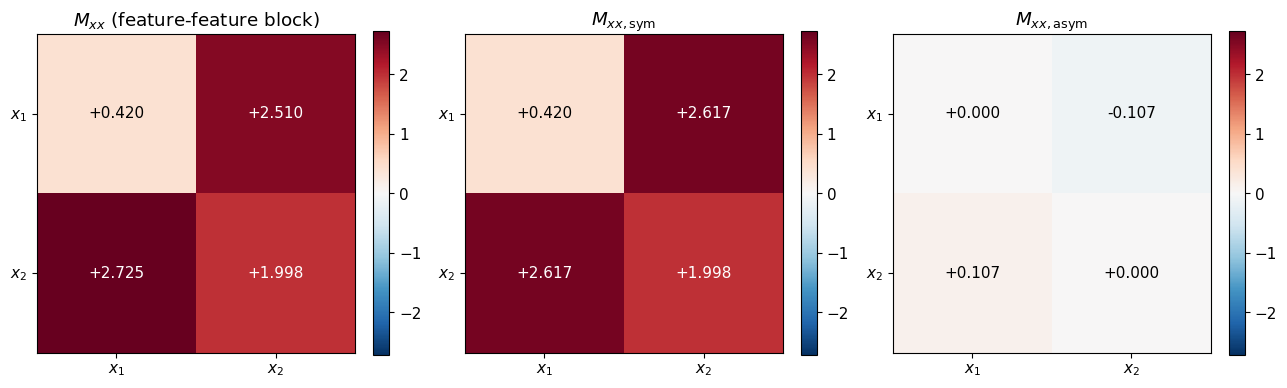

In [20]:
# Heatmap of M_xx and its sym/antisym parts (the W_V variant)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
vmax = max(np.abs(M_xx).max(), np.abs(M_xx_sym).max(), np.abs(M_xx_asym).max())
labels = ['$x_1$', '$x_2$']
for ax, mat, title in zip(axes, [M_xx, M_xx_sym, M_xx_asym],
                          [r'$M_{xx}$ (feature-feature block)',
                           r'$M_{xx,\mathrm{sym}}$',
                           r'$M_{xx,\mathrm{asym}}$']):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    ax.set_title(title)
    for (i, j), v in np.ndenumerate(mat):
        ax.text(j, i, f'{v:+.3f}', ha='center', va='center', fontsize=11,
                color='white' if abs(v) > 0.55*vmax else 'black')
plt.tight_layout()
plt.savefig('fig_M_decomposition_wv.png', dpi=140, bbox_inches='tight')
plt.show()

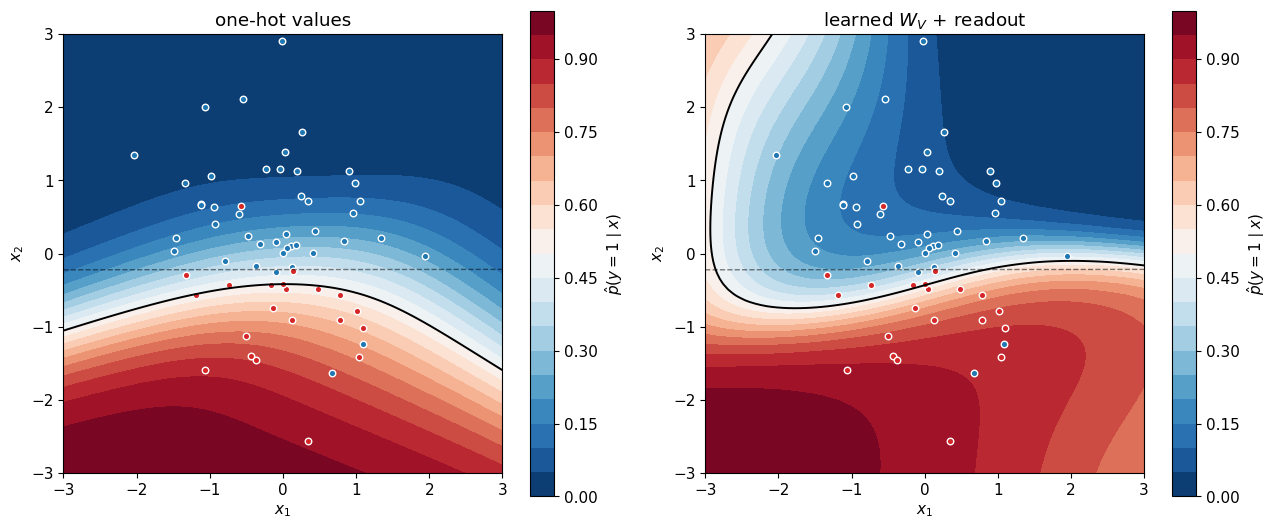

Both models converge to similar decision regions on a held-out task.


In [21]:
# Compare the trained one-hot model and the learned-W_V model on the same task
@torch.no_grad()
def predict_grid(model, X_ctx, y_ctx, grid_n=80):
    xs = np.linspace(-3, 3, grid_n).astype(np.float32)
    XX, YY = np.meshgrid(xs, xs, indexing='xy')
    G = np.stack([XX.ravel(), YY.ravel()], axis=-1).astype(np.float32)
    Xc_t = torch.tensor(X_ctx, device=device).unsqueeze(0)
    yc_t = torch.tensor(y_ctx, device=device).unsqueeze(0)
    G_t = torch.tensor(G, device=device).unsqueeze(0)
    p = model(Xc_t, yc_t, G_t)[0, :, 1].cpu().numpy().reshape(grid_n, grid_n)
    return XX, YY, p

torch.manual_seed(303); np.random.seed(303)
Xc_np, yc_np, _, _, w_t, b_t = sample_episode(64, 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, mdl, title in zip(axes, [model, model_v],
                          ['one-hot values', r'learned $W_V$ + readout']):
    XX, YY, p = predict_grid(mdl, Xc_np, yc_np)
    im = ax.contourf(XX, YY, p, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label=r'$\hat{p}(y=1\mid x)$')
    ax.contour(XX, YY, p, levels=[0.5], colors='black', linewidths=1.4)
    ax.scatter(Xc_np[yc_np==0, 0], Xc_np[yc_np==0, 1], c='C0', s=22, edgecolor='white')
    ax.scatter(Xc_np[yc_np==1, 0], Xc_np[yc_np==1, 1], c='C3', s=22, edgecolor='white')
    xs_line = np.linspace(-3, 3, 50)
    if abs(w_t[1]) > 1e-6:
        ax.plot(xs_line, -(w_t[0]*xs_line + b_t)/w_t[1], 'k--', lw=1, alpha=0.5)
    ax.set_aspect('equal'); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_title(title)
    ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
plt.tight_layout(); plt.show()
print('Both models converge to similar decision regions on a held-out task.')

## 8e. Does the learned kernel actually recover from noise dimensions?

Section 4 made the case that a learned attention kernel can suppress
irrelevant feature directions where a fixed RBF cannot. We can test
this directly. Take the same 2-D linear prior and augment it with
extra Gaussian noise dimensions (the labels still depend only on the
first two features). Train a single-layer attention model with the
augmented input dimension. Compare its held-out accuracy against RBF
Nadaraya--Watson on the same augmented features. The Bayes-optimal
accuracy is $0.95$ throughout.

training learned-kernel model with n_noise=0 ...


  learned attention acc = 0.869   RBF NW acc = 0.898
training learned-kernel model with n_noise=2 ...


  learned attention acc = 0.869   RBF NW acc = 0.826
training learned-kernel model with n_noise=6 ...


  learned attention acc = 0.870   RBF NW acc = 0.714
training learned-kernel model with n_noise=14 ...


  learned attention acc = 0.863   RBF NW acc = 0.665
training learned-kernel model with n_noise=30 ...


  learned attention acc = 0.873   RBF NW acc = 0.607


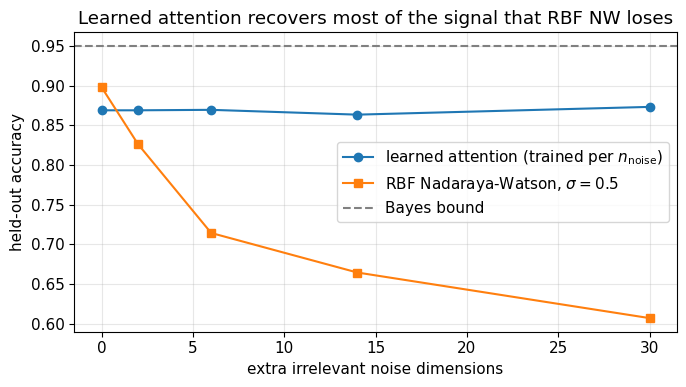

In [22]:
def sample_batch_aug(B, n_ctx, n_q, n_noise):
    d_x = 2 + n_noise
    Xc = np.empty((B, n_ctx, d_x), dtype=np.float32)
    yc = np.empty((B, n_ctx), dtype=np.int64)
    Xq = np.empty((B, n_q,   d_x), dtype=np.float32)
    yq = np.empty((B, n_q),       dtype=np.int64)
    for b in range(B):
        _, _, xc, ycb, xq, yqb, _, _ = sample_episode_with_noise_dims(n_ctx, n_q, n_noise=n_noise)
        Xc[b] = xc; yc[b] = ycb; Xq[b] = xq; yq[b] = yqb
    return tuple(torch.tensor(t) for t in (Xc, yc, Xq, yq))

def train_aug_model(n_noise, n_steps=1500):
    d_x = 2 + n_noise
    torch.manual_seed(0); np.random.seed(0)
    m = SingleLayerNWAttention(d_x=d_x, d_k=16).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=3e-3)
    for step in range(1, n_steps + 1):
        n_ctx = int(np.random.randint(4, 97))
        Xc, yc, Xq, yq = (t.to(device) for t in sample_batch_aug(32, n_ctx, 32, n_noise))
        p = m(Xc, yc, Xq)
        loss = nll_from_probs(p, yq).mean()
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    return m

@torch.no_grad()
def eval_attn_aug(model, n_noise, n_episodes=80, n_ctx=64, n_q=64):
    accs = []
    for _ in range(n_episodes):
        Xc, yc, Xq, yq = sample_batch_aug(1, n_ctx, n_q, n_noise)
        p = model(Xc.to(device), yc.to(device), Xq.to(device))
        accs.append((p.argmax(-1).cpu() == yq).float().mean().item())
    return float(np.mean(accs))

noise_levels = [0, 2, 6, 14, 30]
attn_accs, rbf_accs = [], []
for n_noise in noise_levels:
    print(f'training learned-kernel model with n_noise={n_noise} ...')
    m = train_aug_model(n_noise, n_steps=1200)
    attn_accs.append(eval_attn_aug(m, n_noise))
    accs = []
    for _ in range(80):
        Xc, yc, Xq, yq = sample_batch_aug(1, 64, 64, n_noise)
        p = rbf_nw_predict_proba(Xc.numpy()[0], yc.numpy()[0], Xq.numpy()[0], sigma=0.5)
        accs.append((p.argmax(-1) == yq.numpy()[0]).mean())
    rbf_accs.append(float(np.mean(accs)))
    print(f'  learned attention acc = {attn_accs[-1]:.3f}   RBF NW acc = {rbf_accs[-1]:.3f}')

plt.figure(figsize=(7, 4))
plt.plot(noise_levels, attn_accs, '-o', label='learned attention (trained per $n_{\\mathrm{noise}}$)')
plt.plot(noise_levels, rbf_accs,  '-s', label='RBF Nadaraya-Watson, $\\sigma=0.5$')
plt.axhline(0.95, color='gray', ls='--', label='Bayes bound')
plt.xlabel('extra irrelevant noise dimensions')
plt.ylabel('held-out accuracy')
plt.title('Learned attention recovers most of the signal that RBF NW loses')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('fig_recovery_from_noise.png', dpi=140, bbox_inches='tight')
plt.show()

## 8f. Anisotropic prior: does $M_\mathrm{sym}$ become non-isotropic?

The article predicts that a rotationally symmetric prior produces a
near-isotropic $M_\mathrm{sym}$, and that an anisotropic prior should
produce a non-isotropic $M_\mathrm{sym}$ whose dominant eigenvector
aligns with the prior's preferred direction. We test it directly.

Modify the prior so the boundary direction is concentrated near the
horizontal axis: $w_x = \cos\theta$, $w_y = \sin\theta$ with
$\theta \sim \mathcal{N}(0, 0.3^2)$ (radians). Train a single-layer
model on this prior and inspect the eigenstructure of $M_\mathrm{sym}$.

In [23]:
def sample_aniso_task():
    angle = np.float32(np.random.normal(0.0, 0.3))      # concentrated near 0
    w = np.array([np.cos(angle), np.sin(angle)], dtype=np.float32)
    b = np.float32(np.random.uniform(-0.5, 0.5))
    return w, b

def sample_aniso_episode(n_ctx, n_q):
    w, b = sample_aniso_task()
    X = np.random.randn(n_ctx + n_q, 2).astype(np.float32)
    score = X @ w + b
    y = (score > 0).astype(np.int64)
    flips = np.random.rand(len(y)) < NOISE
    y = np.where(flips, 1 - y, y)
    return X[:n_ctx], y[:n_ctx], X[n_ctx:], y[n_ctx:], w, b

def sample_batch_aniso(B, n_ctx, n_q):
    Xc = np.empty((B, n_ctx, 2), dtype=np.float32)
    yc = np.empty((B, n_ctx),    dtype=np.int64)
    Xq = np.empty((B, n_q,   2), dtype=np.float32)
    yq = np.empty((B, n_q),      dtype=np.int64)
    for b in range(B):
        xc, ycb, xq, yqb, _, _ = sample_aniso_episode(n_ctx, n_q)
        Xc[b] = xc; yc[b] = ycb; Xq[b] = xq; yq[b] = yqb
    return tuple(torch.tensor(t) for t in (Xc, yc, Xq, yq))

torch.manual_seed(0); np.random.seed(0)
model_aniso = SingleLayerNWAttention(d_x=2, d_k=16).to(device)
opt = torch.optim.Adam(model_aniso.parameters(), lr=3e-3)
for step in range(1500):
    n_ctx = int(np.random.randint(4, 97))
    Xc, yc, Xq, yq = (t.to(device) for t in sample_batch_aniso(32, n_ctx, 32))
    p = model_aniso(Xc, yc, Xq)
    loss = nll_from_probs(p, yq).mean()
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()

M_a = extract_M_one_hot(model_aniso)
M_a_sym = 0.5 * (M_a + M_a.T)
eigvals_iso,   _ = la.eigh(M_sym)        # the original isotropic-prior model
eigvals_aniso, eigvecs_aniso = la.eigh(M_a_sym)
print(f'Isotropic-prior   M_sym eigenvalues: {eigvals_iso} (ratio {eigvals_iso.max()/eigvals_iso.min():.2f})')
print(f'Anisotropic-prior M_sym eigenvalues: {eigvals_aniso} (ratio {eigvals_aniso.max()/eigvals_aniso.min():.2f})')
top = eigvecs_aniso[:, np.argmax(eigvals_aniso)]
print(f'Dominant eigenvector of M_sym (anisotropic): {top}')
print('(The anisotropic prior concentrates w near (1, 0); the dominant eigenvector should be roughly aligned.)')

Isotropic-prior   M_sym eigenvalues: [4.9871416 5.2936096] (ratio 1.06)
Anisotropic-prior M_sym eigenvalues: [2.4343827 7.185637 ] (ratio 2.95)
Dominant eigenvector of M_sym (anisotropic): [-0.9999834   0.00576224]
(The anisotropic prior concentrates w near (1, 0); the dominant eigenvector should be roughly aligned.)


## 8g. Calibration diagnostics

The article softens the calibration claim: the Bayesian view explains
why calibration is plausible \emph{under the prior}, but finite
training and prior shift can break it. We check empirically. Collect
many predictions on episodes drawn from (i) the same 2-D linear prior
the model was trained on, and (ii) a shifted prior with a different
noise rate (say 25\%). Plot reliability diagrams and report ECE and
Brier score for each.

In-prior          ECE = 0.096   Brier = 0.123
Shifted prior 25% ECE = 0.053   Brier = 0.230


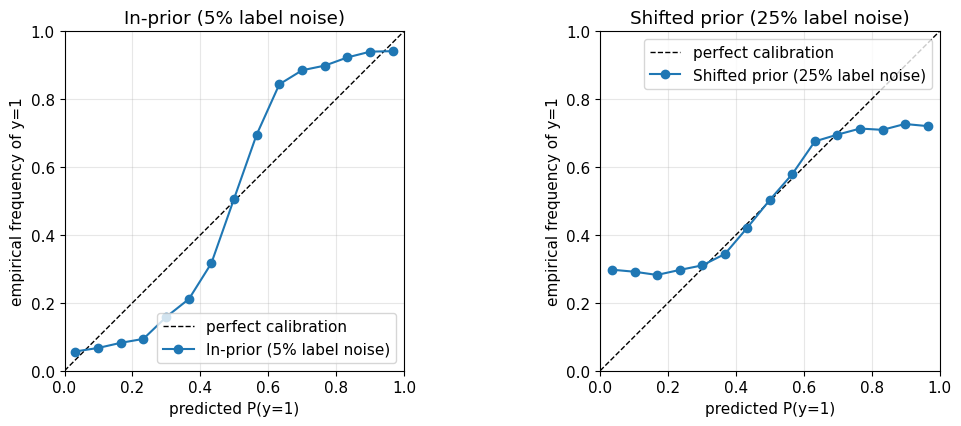

In [24]:
@torch.no_grad()
def collect_predictions(model, sampler, n_episodes=600, n_ctx=64, n_q=32):
    probs_list, labels_list = [], []
    for _ in range(n_episodes):
        Xc, yc, Xq, yq = sampler(1, n_ctx, n_q)
        p = model(Xc.to(device), yc.to(device), Xq.to(device))
        probs_list.append(p[0, :, 1].cpu().numpy())
        labels_list.append(yq[0].numpy())
    return np.concatenate(probs_list), np.concatenate(labels_list)

def reliability(probs, labels, n_bins=15):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(probs, bin_edges) - 1, 0, n_bins - 1)
    pred, obs, cnt = [], [], []
    for b in range(n_bins):
        m = idx == b
        if m.sum() > 0:
            pred.append(probs[m].mean()); obs.append(labels[m].mean()); cnt.append(int(m.sum()))
        else:
            pred.append(np.nan); obs.append(np.nan); cnt.append(0)
    return np.array(pred), np.array(obs), np.array(cnt)

def ece(pred, obs, cnt):
    valid = ~np.isnan(pred)
    return float(np.sum(cnt[valid] * np.abs(pred[valid] - obs[valid])) / cnt[valid].sum())

def brier(probs, labels):
    return float(np.mean((probs - labels) ** 2))

def sample_batch_shifted(B, n_ctx, n_q, noise=0.25):
    Xc = np.empty((B, n_ctx, 2), dtype=np.float32)
    yc = np.empty((B, n_ctx),    dtype=np.int64)
    Xq = np.empty((B, n_q,   2), dtype=np.float32)
    yq = np.empty((B, n_q),      dtype=np.int64)
    for b in range(B):
        w, bb = sample_task()
        X = np.random.randn(n_ctx + n_q, 2).astype(np.float32)
        score = X @ w + bb
        y = (score > 0).astype(np.int64)
        flips = np.random.rand(len(y)) < noise
        y = np.where(flips, 1 - y, y)
        Xc[b] = X[:n_ctx]; yc[b] = y[:n_ctx]
        Xq[b] = X[n_ctx:]; yq[b] = y[n_ctx:]
    return tuple(torch.tensor(t) for t in (Xc, yc, Xq, yq))

probs_in, labels_in = collect_predictions(model, sample_batch)
probs_sh, labels_sh = collect_predictions(model, sample_batch_shifted)

p_in, o_in, c_in = reliability(probs_in, labels_in)
p_sh, o_sh, c_sh = reliability(probs_sh, labels_sh)

print(f'In-prior          ECE = {ece(p_in, o_in, c_in):.3f}   Brier = {brier(probs_in, labels_in):.3f}')
print(f'Shifted prior 25% ECE = {ece(p_sh, o_sh, c_sh):.3f}   Brier = {brier(probs_sh, labels_sh):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, p, o, label in zip(axes, [p_in, p_sh], [o_in, o_sh],
                           ['In-prior (5% label noise)', 'Shifted prior (25% label noise)']):
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='perfect calibration')
    ax.plot(p, o, '-o', label=label)
    ax.set_xlabel('predicted P(y=1)')
    ax.set_ylabel('empirical frequency of y=1')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    ax.set_title(label); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('fig_calibration.png', dpi=140, bbox_inches='tight')
plt.show()

## 8h. Multi-seed uncertainty for the headline metrics

Several claims in the article rely on a single trained toy model. The
last diagnostic retrains five seeds of the same architecture and
reports mean $\pm$ standard deviation for: held-out accuracy, the
asymmetry ratio $\|M_\mathrm{asym}\|_F / \|M_\mathrm{sym}\|_F$ from
section~8b, and the label-swap delta. The point is to make the
sensitivity of these numbers visible, not to chase the smallest
error bar.

In [25]:
@torch.no_grad()
def headline_metrics(m, n_episodes=200, n_ctx=64, n_q=64):
    accs = []
    for _ in range(n_episodes):
        Xc, yc, Xq, yq = sample_batch(1, n_ctx, n_q)
        p = m(Xc.to(device), yc.to(device), Xq.to(device))
        accs.append((p.argmax(-1).cpu() == yq).float().mean().item())
    M_ = extract_M_one_hot(m)
    M_s, M_a = 0.5*(M_ + M_.T), 0.5*(M_ - M_.T)
    asym_ratio = la.norm(M_a) / la.norm(M_s)
    deltas = []
    for _ in range(30):
        Xc, yc, Xq, _ = sample_batch(1, 32, 200)
        Xc, yc, Xq = Xc.to(device), yc.to(device), Xq.to(device)
        p_orig = m(Xc, yc, Xq)
        yc_perm = yc[:, torch.randperm(32)]
        p_perm = m(Xc, yc_perm, Xq)
        deltas.append((p_orig - p_perm).abs().mean().item())
    delta = float(np.mean(deltas))
    return float(np.mean(accs)), float(asym_ratio), float(delta)

results_seeds = []
for seed in range(5):
    torch.manual_seed(seed); np.random.seed(seed)
    m_seed = SingleLayerNWAttention(d_x=2, d_k=16).to(device)
    opt = torch.optim.Adam(m_seed.parameters(), lr=3e-3)
    for step in range(1200):
        n_ctx = int(np.random.randint(4, 97))
        Xc, yc, Xq, yq = (t.to(device) for t in sample_batch(32, n_ctx, 32))
        p = m_seed(Xc, yc, Xq)
        loss = nll_from_probs(p, yq).mean()
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    a, r, d = headline_metrics(m_seed)
    results_seeds.append((a, r, d))
    print(f'seed {seed}: acc={a:.3f}  asym/sym={r:.4f}  label-swap delta={d:.3f}')

results_seeds = np.array(results_seeds)
mean = results_seeds.mean(axis=0); std = results_seeds.std(axis=0)
print()
print(f'                      mean    std')
print(f'held-out accuracy   {mean[0]:.3f}   {std[0]:.3f}')
print(f'asym/sym ratio      {mean[1]:.4f}  {std[1]:.4f}')
print(f'label-swap delta    {mean[2]:.3f}   {std[2]:.3f}')

seed 0: acc=0.867  asym/sym=0.0189  label-swap delta=0.292


seed 1: acc=0.870  asym/sym=0.0134  label-swap delta=0.272


seed 2: acc=0.865  asym/sym=0.0120  label-swap delta=0.247


seed 3: acc=0.867  asym/sym=0.0211  label-swap delta=0.274


seed 4: acc=0.862  asym/sym=0.0007  label-swap delta=0.253

                      mean    std
held-out accuracy   0.866   0.003
asym/sym ratio      0.0132  0.0071
label-swap delta    0.268   0.016


## 8. Bayesian comparison: does the trained model approximate the posterior predictive?

The posterior predictive under our linear prior is
$$
p(y_q \mid x_q, X_{\text{ctx}}, y_{\text{ctx}}) =
  \int p(y_q \mid x_q, \tau)\, p(\tau \mid X_{\text{ctx}}, y_{\text{ctx}})\, d\tau,
$$
which we can compute by importance sampling. We compare it to the
trained ICL model on the same held-out task.

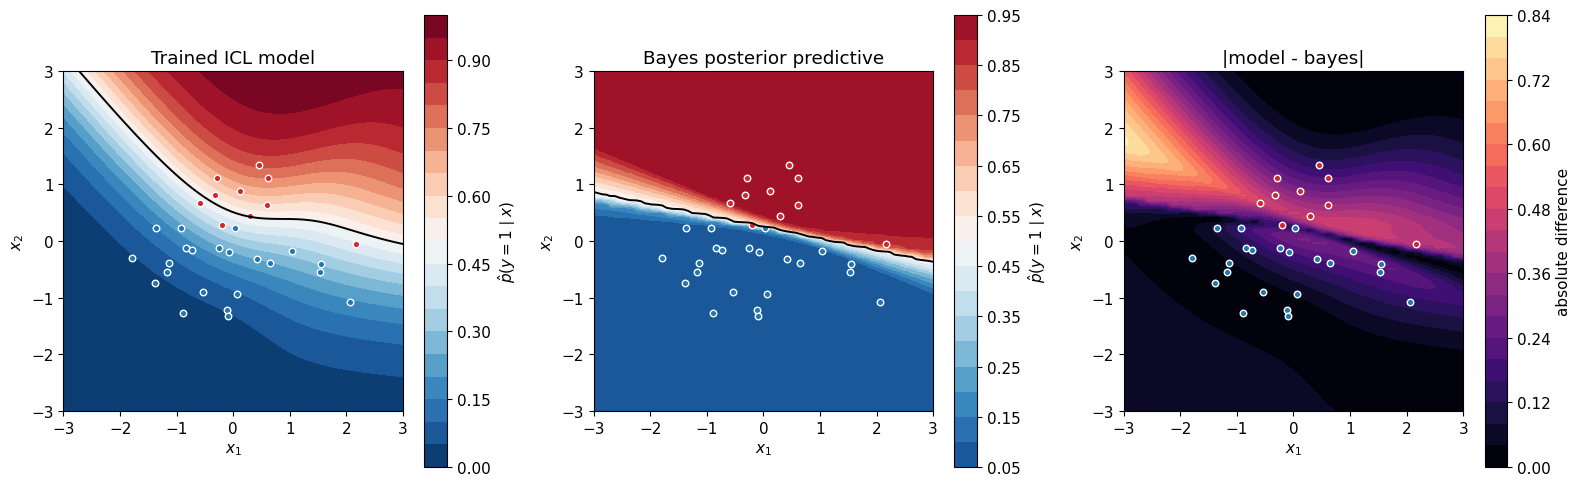

Mean |model - bayes| over the grid: 0.153
Residual gap = approximation error from finite training and finite capacity.


In [26]:
def bayes_posterior_predictive(X_ctx, y_ctx, X_q, n_samples=20000, noise=NOISE):
    angles = np.random.uniform(0, 2*np.pi, n_samples)
    ws = np.stack([np.cos(angles), np.sin(angles)], axis=-1).astype(np.float32)
    bs = np.random.uniform(-0.5, 0.5, n_samples).astype(np.float32)
    scores_ctx = X_ctx @ ws.T + bs
    p1_ctx = np.where(scores_ctx > 0, 1 - noise, noise)
    p_obs = np.where(y_ctx[:, None] == 1, p1_ctx, 1 - p1_ctx)
    log_lik = np.log(p_obs).sum(axis=0)
    log_lik -= log_lik.max()
    weights = np.exp(log_lik); weights /= weights.sum()
    scores_q = X_q @ ws.T + bs
    p1_q = np.where(scores_q > 0, 1 - noise, noise)
    return (p1_q * weights).sum(axis=1)

torch.manual_seed(202); np.random.seed(202)
Xc_np, yc_np, _, _, w_true, b_true = sample_episode(32, 2)
grid_n = 80
xs = np.linspace(-3, 3, grid_n).astype(np.float32)
XX, YY = np.meshgrid(xs, xs, indexing='xy')
grid = np.stack([XX.ravel(), YY.ravel()], axis=-1).astype(np.float32)

with torch.no_grad():
    Xc_t = torch.tensor(Xc_np, device=device).unsqueeze(0)
    yc_t = torch.tensor(yc_np, device=device).unsqueeze(0)
    grid_t = torch.tensor(grid, device=device).unsqueeze(0)
    p_model = model(Xc_t, yc_t, grid_t)[0, :, 1].cpu().numpy().reshape(grid_n, grid_n)

p_bayes = bayes_posterior_predictive(Xc_np, yc_np, grid).reshape(grid_n, grid_n)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, p, title, kind in zip(axes, [p_model, p_bayes, np.abs(p_model - p_bayes)],
                              ['Trained ICL model', 'Bayes posterior predictive', '|model - bayes|'],
                              ['p', 'p', 'd']):
    if kind == 'd':
        im = ax.contourf(XX, YY, p, levels=20, cmap='magma')
        plt.colorbar(im, ax=ax, label='absolute difference')
    else:
        im = ax.contourf(XX, YY, p, levels=20, cmap='RdBu_r', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, label=r'$\hat{p}(y=1\mid x)$')
        ax.contour(XX, YY, p, levels=[0.5], colors='black', linewidths=1.4)
    ax.scatter(Xc_np[yc_np==0, 0], Xc_np[yc_np==0, 1], c='C0', s=22, edgecolor='white')
    ax.scatter(Xc_np[yc_np==1, 0], Xc_np[yc_np==1, 1], c='C3', s=22, edgecolor='white')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
    ax.set_title(title); ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
plt.tight_layout(); plt.savefig('fig_bayes_comparison.png', dpi=140, bbox_inches='tight'); plt.show()
print(f'Mean |model - bayes| over the grid: {np.abs(p_model - p_bayes).mean():.3f}')
print('Residual gap = approximation error from finite training and finite capacity.')

## 9. Sanity checks

Two standard ICL diagnostics.

Label-swap delta: 0.267  (large means real ICL)

  n_ctx =   4   accuracy = 0.688
  n_ctx =   8   accuracy = 0.752
  n_ctx =  16   accuracy = 0.804
  n_ctx =  32   accuracy = 0.836
  n_ctx =  64   accuracy = 0.859
  n_ctx = 128   accuracy = 0.892


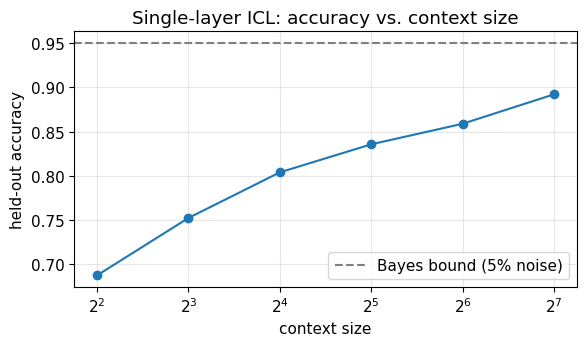

In [27]:
@torch.no_grad()
def label_swap_delta(model, n_episodes=50, n_ctx=32, n_q=200):
    deltas = []
    for _ in range(n_episodes):
        Xc, yc, Xq, _ = sample_batch(1, n_ctx, n_q)
        Xc, yc, Xq = Xc.to(device), yc.to(device), Xq.to(device)
        p_orig = model(Xc, yc, Xq)
        yc_perm = yc[:, torch.randperm(n_ctx)]
        p_perm = model(Xc, yc_perm, Xq)
        deltas.append((p_orig - p_perm).abs().mean().item())
    return float(np.mean(deltas))

@torch.no_grad()
def eval_at_n_ctx(model, n_ctx, n_episodes=80, n_q=64):
    accs = []
    for _ in range(n_episodes):
        Xc, yc, Xq, yq = sample_batch(1, n_ctx, n_q)
        p = model(Xc.to(device), yc.to(device), Xq.to(device))
        accs.append((p.argmax(-1).cpu() == yq).float().mean().item())
    return float(np.mean(accs))

print(f'Label-swap delta: {label_swap_delta(model):.3f}  (large means real ICL)')
sizes = [4, 8, 16, 32, 64, 128]
sweep = [eval_at_n_ctx(model, n) for n in sizes]
for n, a in zip(sizes, sweep):
    print(f'  n_ctx = {n:3d}   accuracy = {a:.3f}')
plt.figure(figsize=(6, 3.6))
plt.plot(sizes, sweep, marker='o')
plt.xscale('log', base=2)
plt.xlabel('context size'); plt.ylabel('held-out accuracy')
plt.axhline(0.95, color='gray', ls='--', label='Bayes bound (5% noise)')
plt.title('Single-layer ICL: accuracy vs. context size')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.savefig('fig_context_scaling.png', dpi=140, bbox_inches='tight'); plt.show()

## 10. Multi-layer in a sentence and the path to TabPFN/TabICL

Stacking layers iterates the same construction in a learned embedding
space. The kernel at layer $\ell+1$ acts on representations
$h^{(\ell)}$ produced by previous layers. With $L \ge 2$, MLPs and
residuals add capacity strictly beyond iterated NW: the model can
implement in-context regression and rule-shaped predictors. The
training target (Bayes posterior predictive under $\pi$) is unchanged.

For depth, see the existing `tabular_icl_transformer.ipynb` for a
multi-layer transformer trained on a 4-D synthetic prior and run on
breast cancer features.

## How this maps onto TabPFN and TabICL

| component        | this notebook              | TabPFN/TabICL                                     |
|------------------|----------------------------|---------------------------------------------------|
| tokenization     | one-hot label values       | TabICL: column-wise + row-wise embedding stage    |
| layers           | 1                          | $\sim$12 with MLP and residual                    |
| mask             | none                       | TabICL: queries attend only to context            |
| positional enc.  | none                       | TabICL: RoPE on the column dimension              |
| prior            | 2-D linear, 5% noise       | TabICL: 70% SCM-MLP, 30% SCM-tree (XGBoost)       |
| inference        | one forward pass           | one forward pass + 32-permutation ensembling      |
| training target  | posterior predictive of $\pi$ | posterior predictive of $\pi$                  |

The bottom row is the only one shared across all three: the kernel
form, the layers, the mask and the prior all change. The geometry
discovery argument applies in every case.
